# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Quesiton 1:**

1. A model is linear only if it is linear in its coefficients(i.e. a linear combination). This means the parameters enter the model additively and are not multiplied by each other. The variables themselves can still be transformed, such as using x^2 or log(x) and they will still be considered linear.
2. The coefficient on a dummy variable shows the difference in the predicted outcome between that group and the reference group, holding other variables constant. If the model includes an intercept, one category is left out and becomes the baseline.
3. It can be used, but it is usually not appropriate. For a binary outcome, linear regression can give predicted values below 0 or above 1, which do not make sense as probabilities. It also does not model classification as well as logistic regression, which is usually preferred.
4. A main sign is that the model fits the training data very well but performs poorly on test data. Another sign is unstable coefficients or a model that changes a lot with small changes in the sample. This suggests the model is fitting noise instead of the true pattern.
5. Multicollinearity means one explanatory variable is highly related to other explanatory variables. In a first-stage regression, if you regress one predictor on the others and get a high R^2, then that predictor does not contain much independent information. In the main regression, this makes it hard to separate its individual effect, so coefficient estimates become unstable and standard errors become large. This indicates existance of bias.
6. You can add transformed variables such as squares, cubes, logs, or interaction terms. This keeps the model linear in coefficients while allowing nonlinear patterns in the data.
7. The slope coefficient shows how much the expected value of 'y' changes when that variable increases by one unit, holding all other variables constant. So each coefficient is a partial effect after controlling for the other regressors.
8. A train/test split divides the data once into a training set and a test set. It is simple, but the result can depend on the specific split. k-fold cross validation splits the data into k parts and repeats training/testing k times, which usually gives a more reliable measure of model performance.
9. The value of k is usually chosen as a balance between accuracy and computation time. Common choices are 5 or 10 folds.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [41]:
! git clone https://github.com/anishjagota/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [42]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/Q1_clean.csv')

In [43]:
df.columns = df.columns.str.strip()
df = df.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})

print(df.columns)
df.head()



Index(['Price', 'Review_Scores_Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


,Price,Review_Scores_Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


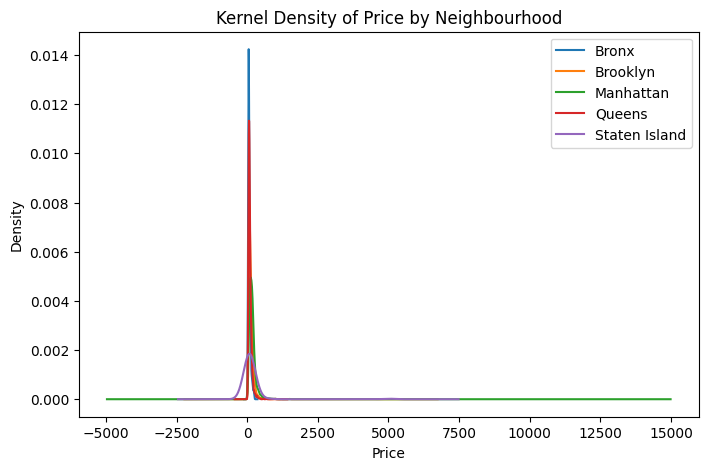

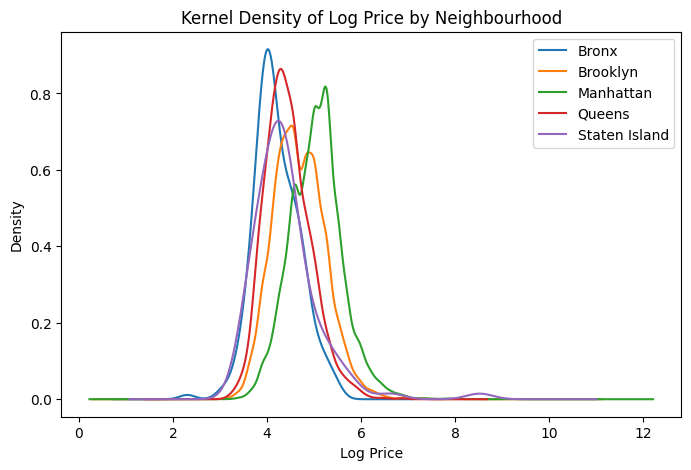

In [44]:
#2.1
means = df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean().sort_values('Price', ascending=False)
print(means)

for col, label in [('Price', 'Price'), ('log_price', 'Log Price')]:
    if col == 'log_price':
        df[col] = np.log(df['Price'])
    plt.figure(figsize=(8,5))
    for n, g in df.groupby('Neighbourhood'):
        g[col].plot(kind='density', label=n)
    plt.xlabel(label)
    plt.title(f'Kernel Density of {label} by Neighbourhood')
    plt.legend()
    plt.show()

In [45]:
#2.2
m2 = smf.ols('Price ~ C(Neighbourhood)', data=df).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:16:58   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Because the model includes an intercept, one neighbourhood is omitted as the reference group.

In [46]:
#2.3
m3 = smf.ols('Price ~ Review_Scores_Rating', data=df).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:17:00   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

A 1-point increase in review score is associated with about a 1.02 increase in price per night, on average.

In [47]:
#2.4
m4 = smf.ols('Price ~ C(Neighbourhood) + Review_Scores_Rating', data=df).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:17:02   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

The coefficient on Review_Scores_Rating changes from 1.0208 in part 3 to 1.0811 here.

In [48]:
#2.5
m5 = smf.ols('Price ~ C(Neighbourhood) * Review_Scores_Rating', data=df).fit()
print(m5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:17:04   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The slopes are similar for Bronx, Brooklyn, Manhattan, and Queens in the sense that they are all fairly small to modest. But Staten Island is very different, with a large negative slope.

In [49]:
#2.6

def run_cv(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []
    for train_idx, test_idx in kf.split(data):
        train_data = data.iloc[train_idx]
        test_data = data.iloc[test_idx]

        model = smf.ols(formula, data=train_data).fit()
        pred = model.predict(test_data)
        mse = mean_squared_error(test_data['Price'], pred)
        errors.append(mse)
    return sum(errors) / len(errors)
m3 = run_cv('Price ~ Review_Scores_Rating', df)
m4 = run_cv('Price ~ C(Neighbourhood) + Review_Scores_Rating', df)
m5 = run_cv('Price ~ C(Neighbourhood) * Review_Scores_Rating', df)
print('CV 3 MSE:', m3)
print('CV 4 MSE:', m4)
print('CV 5 MSE:', m5)

CV 3 MSE: 22075.90663379446
CV 4 MSE: 21065.599711789517
CV 5 MSE: 21309.173811349134


Using cross-validation, the model from part 4 performs best if it has the lowest MSE. That means adding Neighbourhood improves prediction relative to using Review_Scores_Rating alone.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [50]:
cars = pd.read_csv('/content/undergrad_ml_assignments/data/cars_hw.csv')
cars.head()
cars.columns = cars.columns.str.strip()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

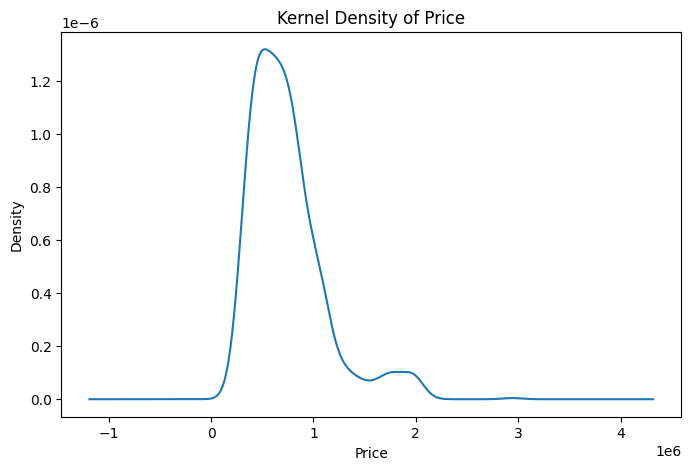

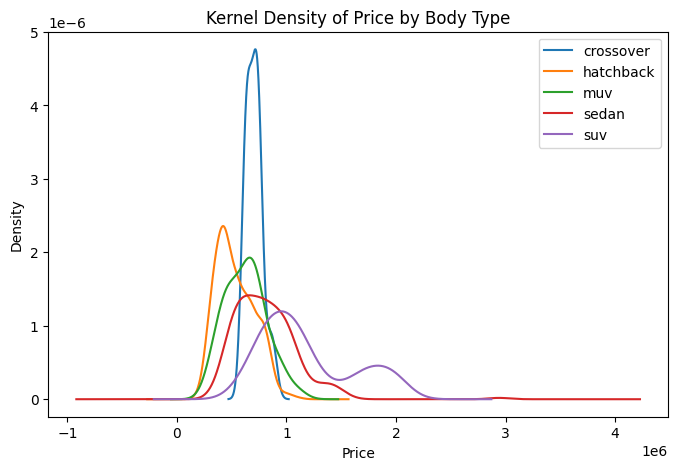

In [51]:
#3.1
print(cars['Price'].describe())
print(cars.groupby('Body_Type')['Price'].describe())

plt.figure(figsize=(8,5))
cars['Price'].plot(kind='density')
plt.xlabel('Price')
plt.title('Kernel Density of Price')
plt.show()

plt.figure(figsize=(8,5))
for b, g in cars.groupby('Body_Type'):
    g['Price'].plot(kind='density', label=b)
plt.xlabel('Price')
plt.title('Kernel Density of Price by Body Type')
plt.legend()
plt.show()

Sedan seems to have the highest average price and SUV seems to have the largest variance/std.

In [52]:
#3.2
m1 = smf.ols('Price ~ Seating_Capacity', data=cars).fit()
print(m1.summary())
m2 = smf.ols('Price ~ C(Seating_Capacity)', data=cars).fit()
print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0245
Time:                        23:17:18   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

A one seat increase in seating capacity is associated with about a 59,270 increase in price, on average. Also, from the output price differences are not very linear in the number of seats. Since it does not increase smoothly with seat count. Treating it as categorical captures the pattern better.

In [53]:
#3.3

cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]
results = {}
for d in range(1, 6):
    formula = "Price ~ " + " + ".join([f"I(Age**{i})" for i in range(1, d+1)])
    results[d] = run_cv(formula, cars)

print(results)
best_degree = min(results, key=results.get)
print("Best degree:", best_degree)

{1: 97745760011.44075, 2: 97815319552.31635, 3: 97304076284.38512, 4: 96785385468.56613, 5: 95816293470.44449}
Best degree: 5


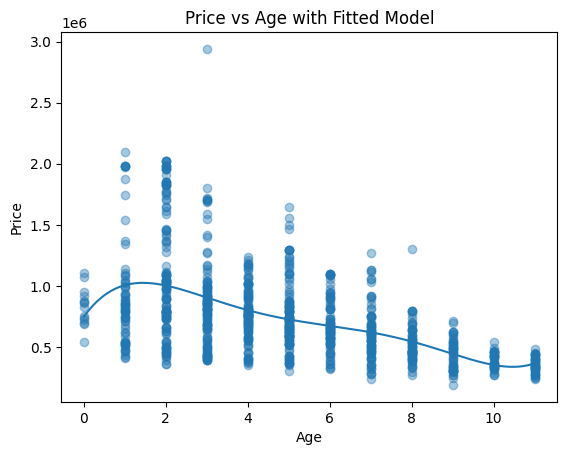

In [54]:
#3.4

best_model = smf.ols('Price ~ Age + I(Age**2) + I(Age**3) + I(Age**4) + I(Age**5)', data=cars).fit()
age_vals = np.linspace(cars['Age'].min(), cars['Age'].max(), 200)
pred_df = pd.DataFrame({'Age': age_vals})
pred_price = best_model.predict(pred_df)
plt.scatter(cars['Age'], cars['Price'], alpha=0.4)
plt.plot(age_vals, pred_price)
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age with Fitted Model')
plt.show()

The plot shows that car price generally decreases as age increases. The fitted curve captures the main downward trend reasonably well, but there is still a lot of spread in prices at each age.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [55]:
heart = pd.read_csv('/content/undergrad_ml_assignments/data/heart_hw.csv')
heart.columns = heart.columns.str.strip()

In [56]:
#4.1
rates = heart.groupby('transplant')['y'].mean()
control = rates['control']
treatment = rates['treatment']
ate = treatment - control
print('Control survival rate:', control)
print('Treatment survival rate:', treatment)
print('ATE:', ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


Transplant patients have about a 23 percentage point higher three-year survival rate than control patients

In [57]:
#4.2
m2 = smf.ols('y ~ C(transplant)', data=heart).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0133
Time:                        23:17:31   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

This perfectly matches part 4.1. The intercept is the control group survival rate and the treatment coefficient is the difference between treatment and control, which is the ATE.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000357
Time:                        23:17:34   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

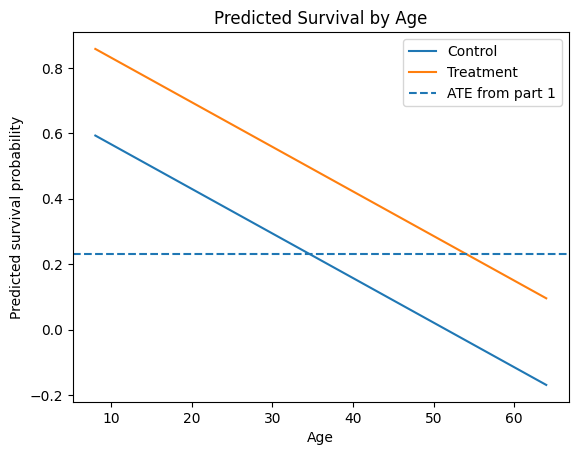

In [58]:
#4.3
m3 = smf.ols('y ~ C(transplant) + age', data=heart).fit()
print(m3.summary())

grid = pd.DataFrame({'age': np.linspace(heart['age'].min(), heart['age'].max(), 100)})
control_pred = grid.copy()
control_pred['transplant'] = 'control'
treat_pred = age_grid.copy()
treat_pred['transplant'] = 'treatment'

plt.plot(age_grid['age'], m3.predict(control_pred), label='Control')
plt.plot(age_grid['age'], m3.predict(treat_pred), label='Treatment')
plt.axhline(ate, linestyle='--', label='ATE from part 1')
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Predicted Survival by Age')
plt.legend()
plt.show()

After controlling for age, the transplant effect increases from 0.2302 to 0.2647. Age has a negative coefficient, so older patients are less likely to survive. Because the treatment and control lines are parallel, the transplant effect stays the same at every age. Since 0.2647 is bigger than the part 1 ATE of 0.2302, ATE understates the transplant effect for all ages.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000310
Time:                        23:17:36   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

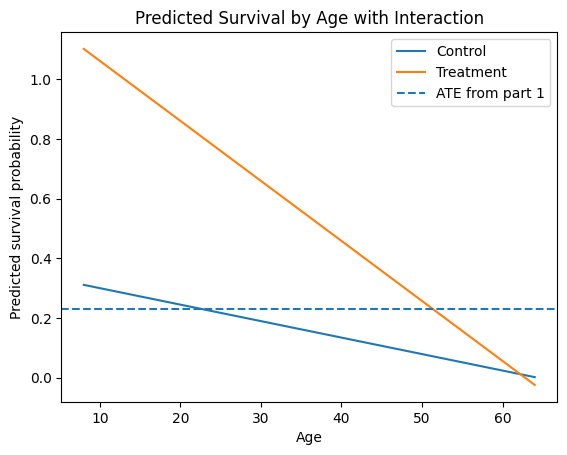

In [59]:
#4.4

m4 = smf.ols('y ~ C(transplant) * age', data=heart).fit()
print(m4.summary())
age_grid = pd.DataFrame({'age': np.linspace(heart['age'].min(), heart['age'].max(), 100)})
control_pred = age_grid.copy()
control_pred['transplant'] = 'control'
treat_pred = age_grid.copy()
treat_pred['transplant'] = 'treatment'

plt.plot(age_grid['age'], m4.predict(control_pred), label='Control')
plt.plot(age_grid['age'], m4.predict(treat_pred), label='Treatment')
plt.axhline(ate, linestyle='--', label='ATE from part 1')
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Predicted Survival by Age with Interaction')
plt.legend()
plt.show()

After adding the interaction term, the transplant effect is no longer constant across age. The negative interaction coefficient means the benefit of transplant decreases as age increases. The model suggests transplant is much more beneficial for younger patients, while the effect becomes much smaller for older patients. Compared with the earlier ATE, the ATE now understates the effect for younger patients and overstates it for older patients

In [60]:
#4.5

def run_cv(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    scores = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        model = smf.ols(formula, data=train).fit()
        pred = model.predict(test)
        scores.append(mean_squared_error(test['y'], pred))
    return np.mean(scores)
cv2 = run_cv('y ~ C(transplant)', heart)
cv3 = run_cv('y ~ C(transplant) + age', heart)
cv4 = run_cv('y ~ C(transplant) * age', heart)
print('CV 2 MSE:', cv2)
print('CV 3 MSE:', cv3)
print('CV 4 MSE:', cv4)


CV 2 MSE: 0.19497249586192153
CV 3 MSE: 0.17926415954952163
CV 4 MSE: 0.17880206762517423


Lower MSE means better predictive accuracy. Adding age clearly improves prediction compared with using transplant alone. The interaction model 4 has the lowest CV MSE, so it performs best, but only by a very small margin over model 3.

**4.6:**

This is a simple linear model being used for a high stakes medical decision, so it should not be independently used to prioritize transplants. One concern is that the data are observational, so the estimated transplant effect may have observational biases through things like differences between patients beyond just age. There are also fairness concerns,  inequalities in treatment or access to care.